# Understanding Principal Component Analysis (PCA)

## Introduction

Principal Component Analysis (PCA) is one of the most widely used dimension reduction techniques in data science and machine learning. It's a powerful method for:

- Reducing the dimensionality of data
- Identifying patterns in data
- Visualizing high-dimensional datasets
- Preprocessing before applying other machine learning algorithms

In this notebook, we'll explore how PCA works, from the mathematical foundations to practical implementation with Python.

## 1. The Problem: High-Dimensional Data

Let's start by considering why we need PCA in the first place.


In [46]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [47]:
# Set random seed for reproducibility
np.random.seed(42)

# Let's create a simple 2D dataset to visualize
n_samples = 100
# Create correlated data
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]  # Covariance matrix with strong correlation
X = np.random.default_rng().multivariate_normal(mean, cov, n_samples)

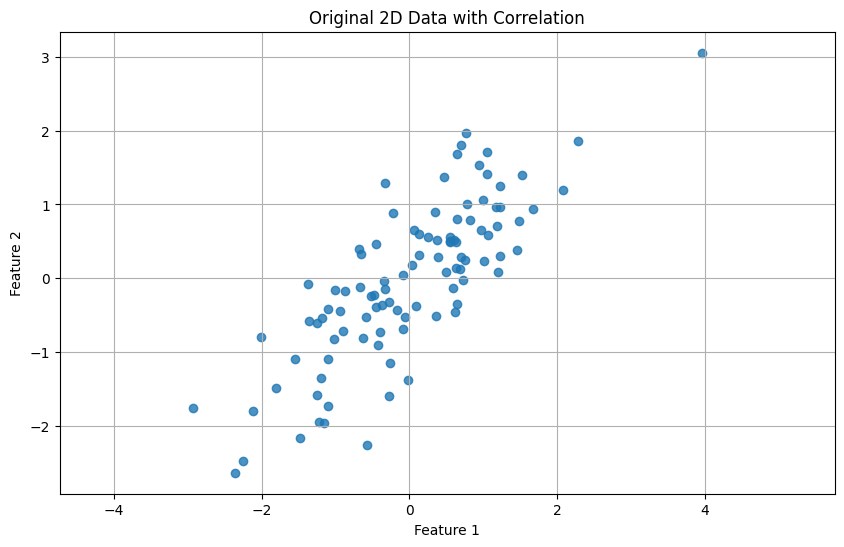

In [48]:
# Plot the original data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.8)
plt.title('Original 2D Data with Correlation')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.axis('equal')
plt.show()

In the real world, data often comes with many more dimensions (features) than just 2 or 3. With high-dimensional data, we face several challenges:

- Visualization becomes difficult
- Computation becomes expensive
- The "curse of dimensionality" makes algorithms less effective
- Many features may be correlated, containing redundant information

## 2. The Intuition Behind PCA

PCA finds new directions (principal components) in the data that:

1. Capture the maximum variance in the data
2. Are orthogonal (perpendicular) to each other
3. Allow us to represent the data with fewer dimensions while preserving as much information as possible

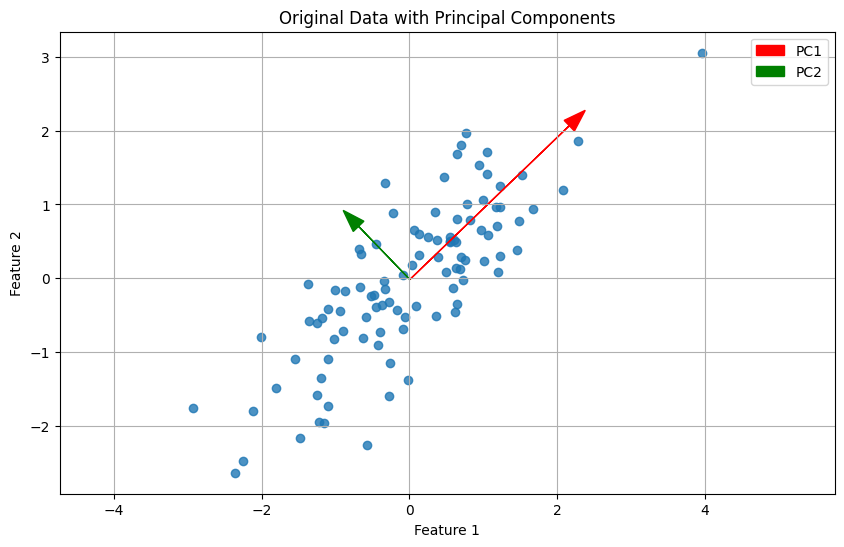

In [49]:
# Plot the same data but now showing the principal components
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.8)


# Calculate mean
mean_x, mean_y = np.mean(X, axis=0)

# Calculate eigenvectors and eigenvalues
cov_matrix = np.cov(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvectors by eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# First principal component
v1 = sorted_eigenvectors[:, 0]
# Second principal component
v2 = sorted_eigenvectors[:, 1]

# Plot principal components
plt.arrow(mean_x, mean_y, v1[0]*3, v1[1]*3, head_width=0.2, head_length=0.3, fc='red', ec='red', label='PC1')
plt.arrow(mean_x, mean_y, v2[0]*1, v2[1]*1, head_width=0.2, head_length=0.3, fc='green', ec='green', label='PC2')

plt.title('Original Data with Principal Components')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.axis('equal')
plt.legend()

In the plot above:
- The red arrow shows the direction of maximum variance (first principal component)
- The green arrow shows the second principal component, orthogonal to the first

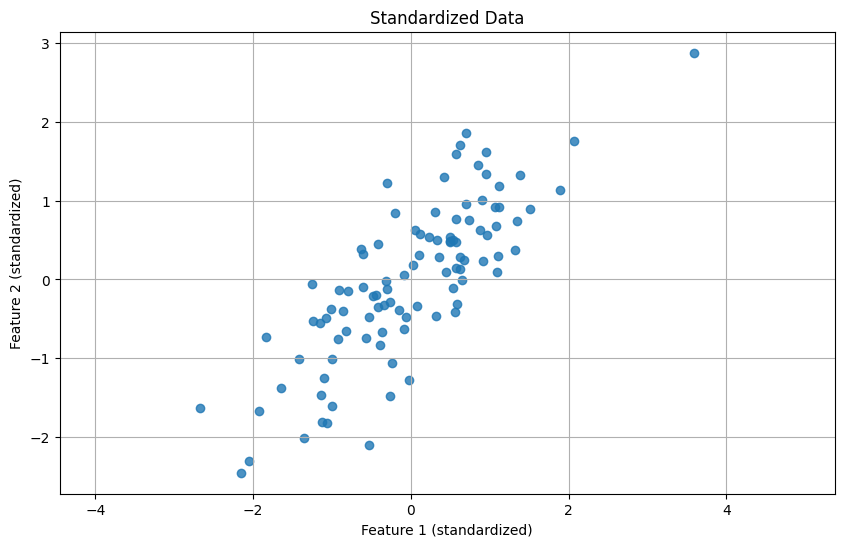

In [50]:
## 3. The Mathematical Foundation of PCA

### Step 1: Standardize the data

# We typically start by standardizing the data to have mean 0 and variance 1 for each feature.
# Standardize the data
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.8)
plt.title('Standardized Data')
plt.xlabel('Feature 1 (standardized)')
plt.ylabel('Feature 2 (standardized)')
plt.grid(True)
plt.axis('equal')
plt.show()


In [51]:
### Step 2: Calculate the covariance matrix

# The covariance matrix tells us how features vary with respect to each other.

In [52]:
# Calculate covariance matrix
cov_matrix = np.cov(X_std, rowvar=False)
print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[1.01010101 0.81466254]
 [0.81466254 1.01010101]]


In [53]:

### Step 3: Calculate the eigenvectors and eigenvalues of the covariance matrix

# The eigenvectors of the covariance matrix give us the directions of the principal components, while the eigenvalues tell us the variance along those directions.
# Calculate eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Display the eigenvectors and eigenvalues
print("\nEigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)

# Sort eigenvectors by decreasing eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("\nSorted Eigenvalues:")
print(sorted_eigenvalues)
print("\nSorted Eigenvectors (Principal Components):")
print(sorted_eigenvectors)




Eigenvalues:
[1.82476355 0.19543847]

Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Sorted Eigenvalues:
[1.82476355 0.19543847]

Sorted Eigenvectors (Principal Components):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [72]:
## Step 4: Select the top k eigenvectors and project the data

# We choose how many dimensions to keep based on:
# - Explained variance ratio
# - Application requirements
# - Computation constraints

Explained Variance Ratio: [0.90325796 0.09674204]


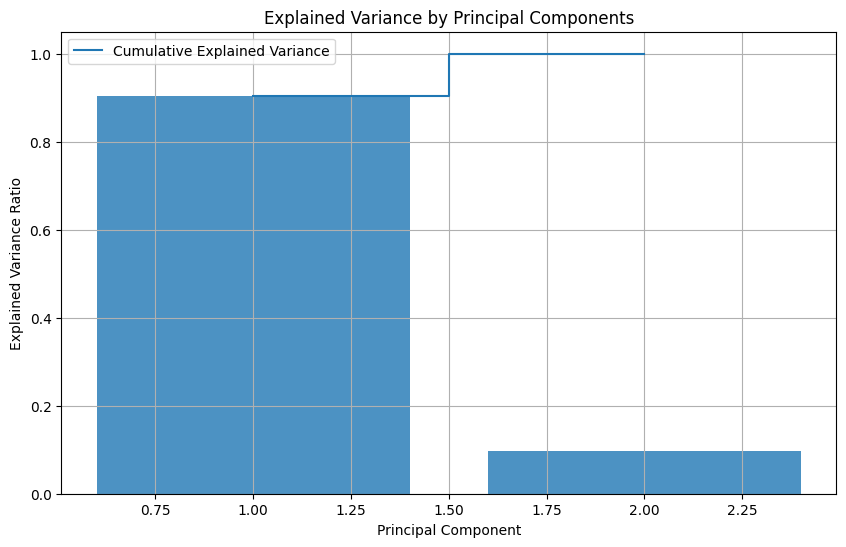

In [54]:
# Calculate explained variance ratio
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
print("Explained Variance Ratio:", explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.8)
plt.step(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), where='mid', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.legend()
plt.show()

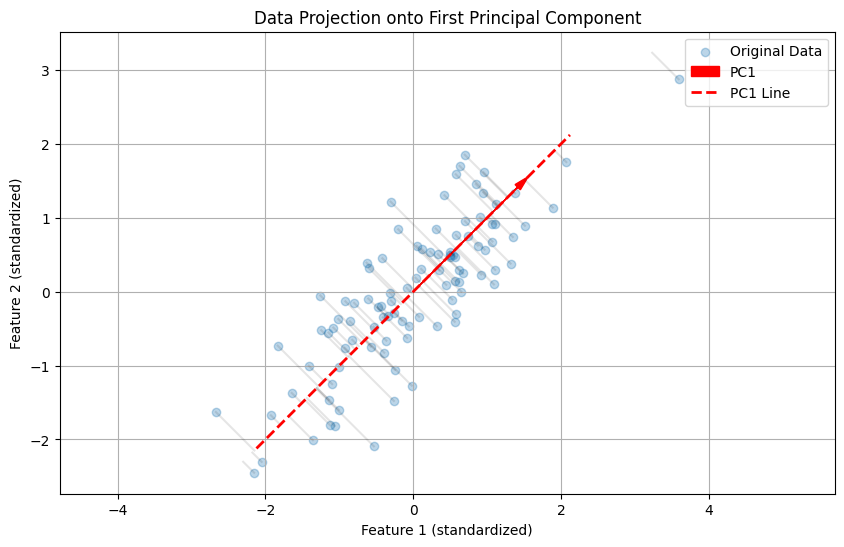

In [55]:
### Step 5: Transform the data to the new feature space

# Finally, we project the data onto the selected principal components.
# Use only the first principal component (dimension reduction from 2D to 1D)
W = sorted_eigenvectors[:, 0].reshape(2, 1)

# Project the data
X_pca_1d = X_std.dot(W)

# Plot the original data and the projection onto the first PC
plt.figure(figsize=(10, 6))
plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.3, label='Original Data')

# For each data point, draw a line to its projection on the first principal component
for i in range(len(X_std)):
    # Calculate the projection point in the original space
    proj_point = X_pca_1d[i] * W.flatten()
    plt.plot([X_std[i, 0], proj_point[0]], [X_std[i, 1], proj_point[1]], 'k-', alpha=0.1)

# Plot the first principal component direction
pc1 = sorted_eigenvectors[:, 0]
plt.arrow(0, 0, pc1[0]*2, pc1[1]*2, head_width=0.1, head_length=0.2, fc='red', ec='red', label='PC1')

# Plot the projection line (PC1)
pc1_line = np.vstack([pc1 * -3, pc1 * 3])
plt.plot(pc1_line[:, 0], pc1_line[:, 1], 'r--', linewidth=2, label='PC1 Line')

plt.title('Data Projection onto First Principal Component')
plt.xlabel('Feature 1 (standardized)')
plt.ylabel('Feature 2 (standardized)')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

### 4. PCA in Higher Dimensions

Let's create a 3D dataset to visualize how PCA works in higher dimensions.

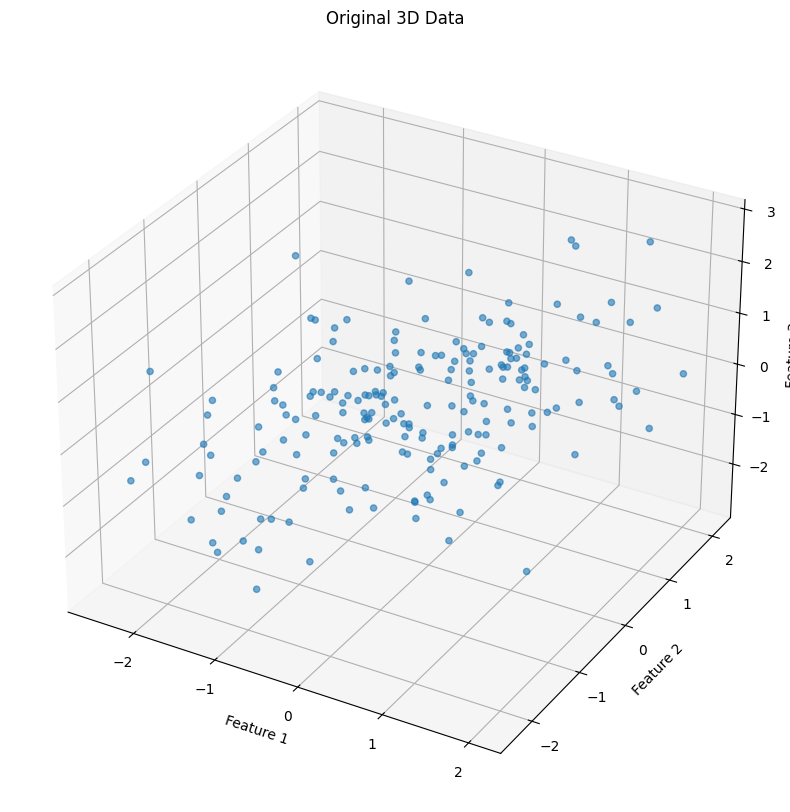

In [56]:
# Create a 3D dataset
n_samples = 200
# Covariance matrix with correlations
cov_3d = [
    [1.0, 0.8, 0.3],
    [0.8, 1.0, 0.5],
    [0.3, 0.5, 1.0]
]
mean_3d = [0, 0, 0]
X_3d = np.random.multivariate_normal(mean_3d, cov_3d, n_samples)

# Plot the 3D data
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], alpha=0.6)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('Original 3D Data')
plt.show()

In [57]:
# Standardize the 3D data
X_3d_std = StandardScaler().fit_transform(X_3d)

# Apply PCA
pca_3d = PCA()
X_3d_pca = pca_3d.fit_transform(X_3d_std)

# Display explained variance ratios
print("Explained Variance Ratio:", pca_3d.explained_variance_ratio_)
print("Cumulative Explained Variance:", np.cumsum(pca_3d.explained_variance_ratio_))

Explained Variance Ratio: [0.66369194 0.26705834 0.06924972]
Cumulative Explained Variance: [0.66369194 0.93075028 1.        ]


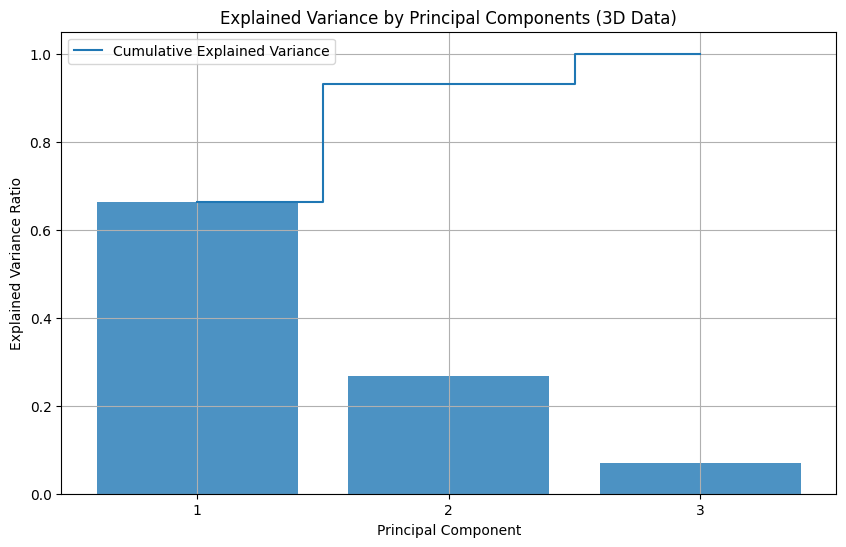

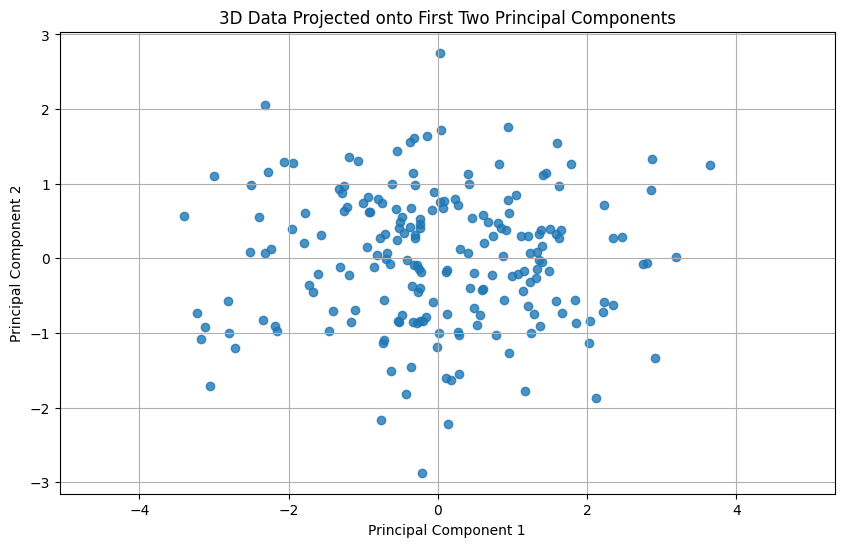

In [58]:
# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, 4), pca_3d.explained_variance_ratio_, alpha=0.8)
plt.step(range(1, 4), np.cumsum(pca_3d.explained_variance_ratio_), where='mid', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components (3D Data)')
plt.xticks([1, 2, 3])
plt.grid(True)
plt.legend()
plt.show()

# Plot the first two principal components
plt.figure(figsize=(10, 6))
plt.scatter(X_3d_pca[:, 0], X_3d_pca[:, 1], alpha=0.8)
plt.title('3D Data Projected onto First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.axis('equal')
plt.show()

### 5. Practical Application: Using PCA with scikit-learn

In [59]:
# Now let's use scikit-learn's implementation of PCA on a real dataset.
from sklearn.datasets import load_iris
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names


In [60]:
# Standardize the data
X_std = StandardScaler().fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Display explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", np.cumsum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.72962445 0.22850762 0.03668922 0.00517871]
Cumulative Explained Variance: [0.72962445 0.95813207 0.99482129 1.        ]


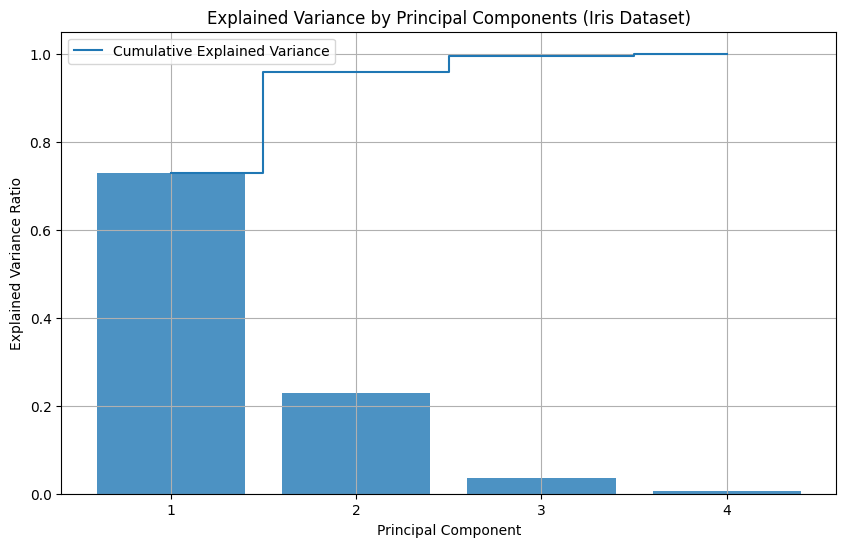

In [61]:
# Plot explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.8)
plt.step(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components (Iris Dataset)')
plt.xticks([1, 2, 3, 4])
plt.grid(True)
plt.legend()
plt.show()


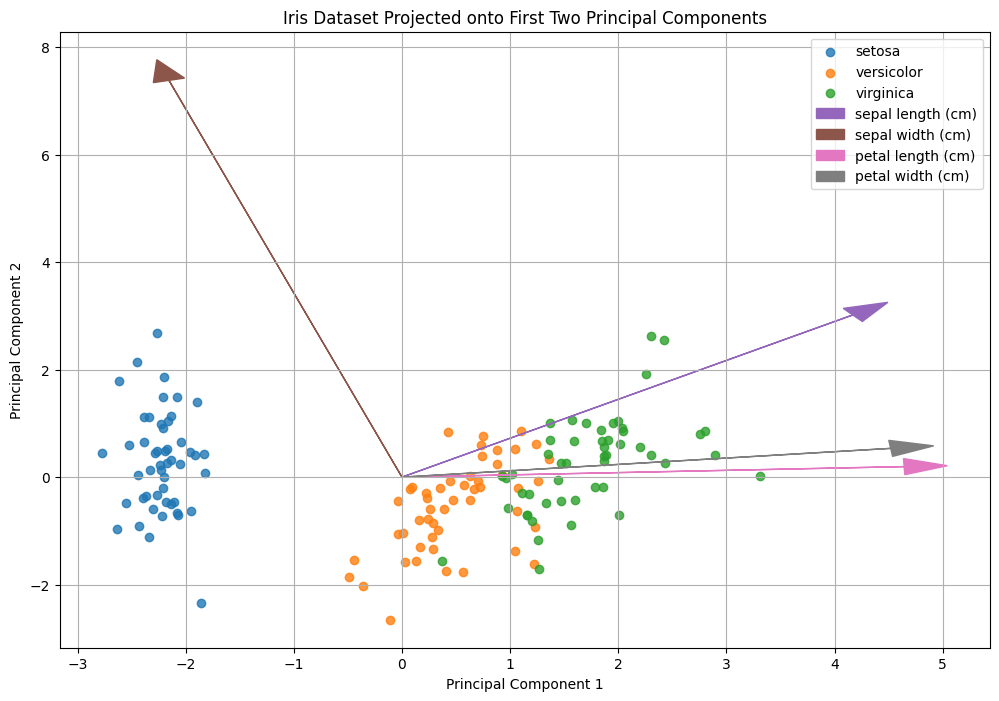

In [62]:
# Plot the first two principal components with class labels
plt.figure(figsize=(12, 8))
for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], alpha=0.8, label=target_name)

# Add feature vectors as arrows
for i, (feature, pca_comp) in enumerate(zip(feature_names, pca.components_.T)):
    plt.arrow(0, 0, pca_comp[0]*8, pca_comp[1]*8, head_width=0.3, head_length=0.4, fc=f'C{i+4}', ec=f'C{i+4}', label=feature)

plt.title('Iris Dataset Projected onto First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()

### 6. Choosing the Number of Principal Components

How many principal components should we keep? There are several approaches:

In [63]:
### a) Based on explained variance ratio
# Function to find the number of components that explain a desired variance
def find_n_components(explained_variance_ratio, threshold=0.95):
    cumulative = np.cumsum(explained_variance_ratio)
    n_components = np.argmax(cumulative >= threshold) + 1
    return n_components


Number of components to explain 95% of variance: 3


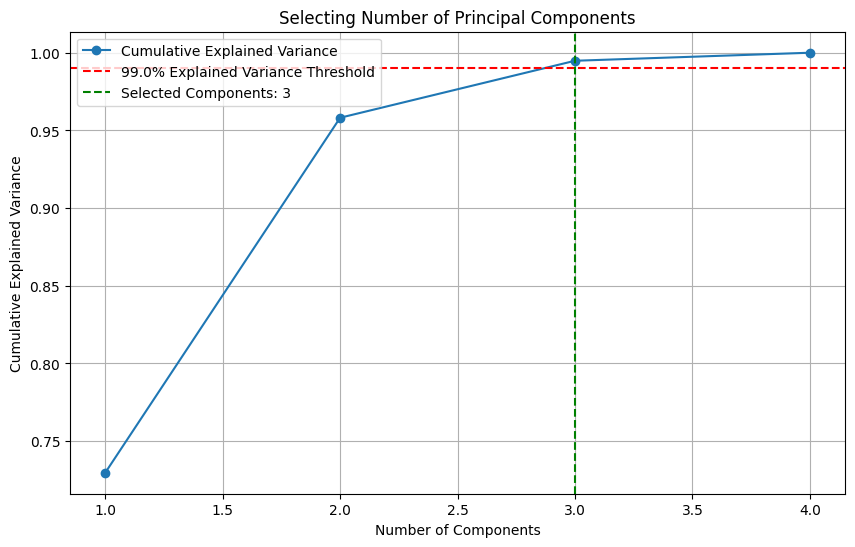

In [64]:
# For Iris dataset
_threshold = 0.99
n_components = find_n_components(pca.explained_variance_ratio_, threshold=_threshold)
print(f"Number of components to explain 95% of variance: {n_components}")

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 
         marker='o', linestyle='-', label='Cumulative Explained Variance')
plt.axhline(y=_threshold, color='r', linestyle='--', label=f'{_threshold*100}% Explained Variance Threshold')
plt.axvline(x=n_components, color='g', linestyle='--', label=f'Selected Components: {n_components}')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Selecting Number of Principal Components')
plt.legend(loc='best')
plt.grid(True)
plt.show()

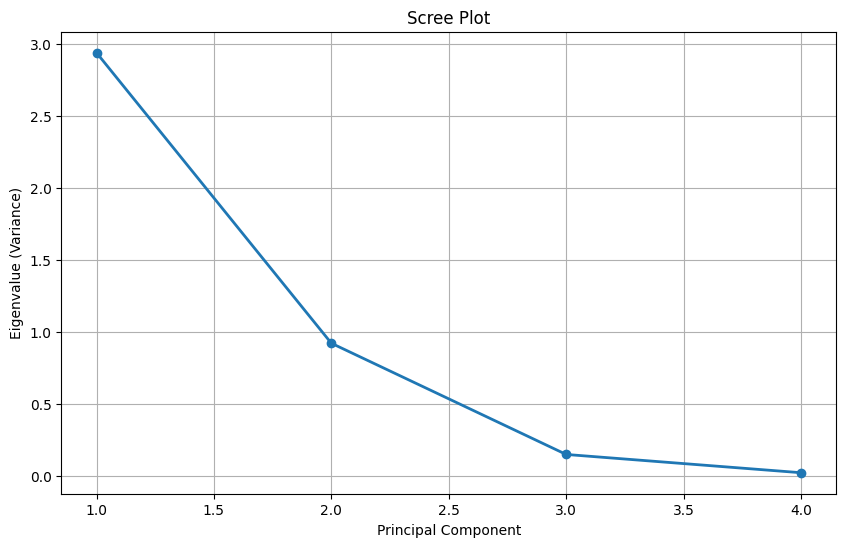

In [65]:
### b) Using Scree Plot (Elbow Method)
# Plot scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_, 'o-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Variance)')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

### 7. Reconstructing the Data from Principal Components
One way to understand PCA is to see how well we can reconstruct the original data using a reduced number of components.


In [66]:
# Function to reconstruct data from PCA components
def reconstruct_from_pca(pca, X_pca, n_components):
    # Use only the first n_components
    X_pca_reduced = X_pca.copy()
    X_pca_reduced[:, n_components:] = 0
    
    # Inverse transform to get back to original space
    X_reconstructed = np.dot(X_pca_reduced, pca.components_)
    X_reconstructed += pca.mean_
    
    return X_reconstructed

In [67]:
# Reconstruct Iris data using different numbers of components
# First, refit PCA without standardization for easier visualization
pca_reconstruct = PCA().fit(X)
X_pca_full = pca_reconstruct.transform(X)

# Create reconstructions with different numbers of components
reconstructions = []
n_features = X.shape[1]
for n in range(1, n_features + 1):
    reconstruction = reconstruct_from_pca(pca_reconstruct, X_pca_full, n)
    reconstructions.append(reconstruction)


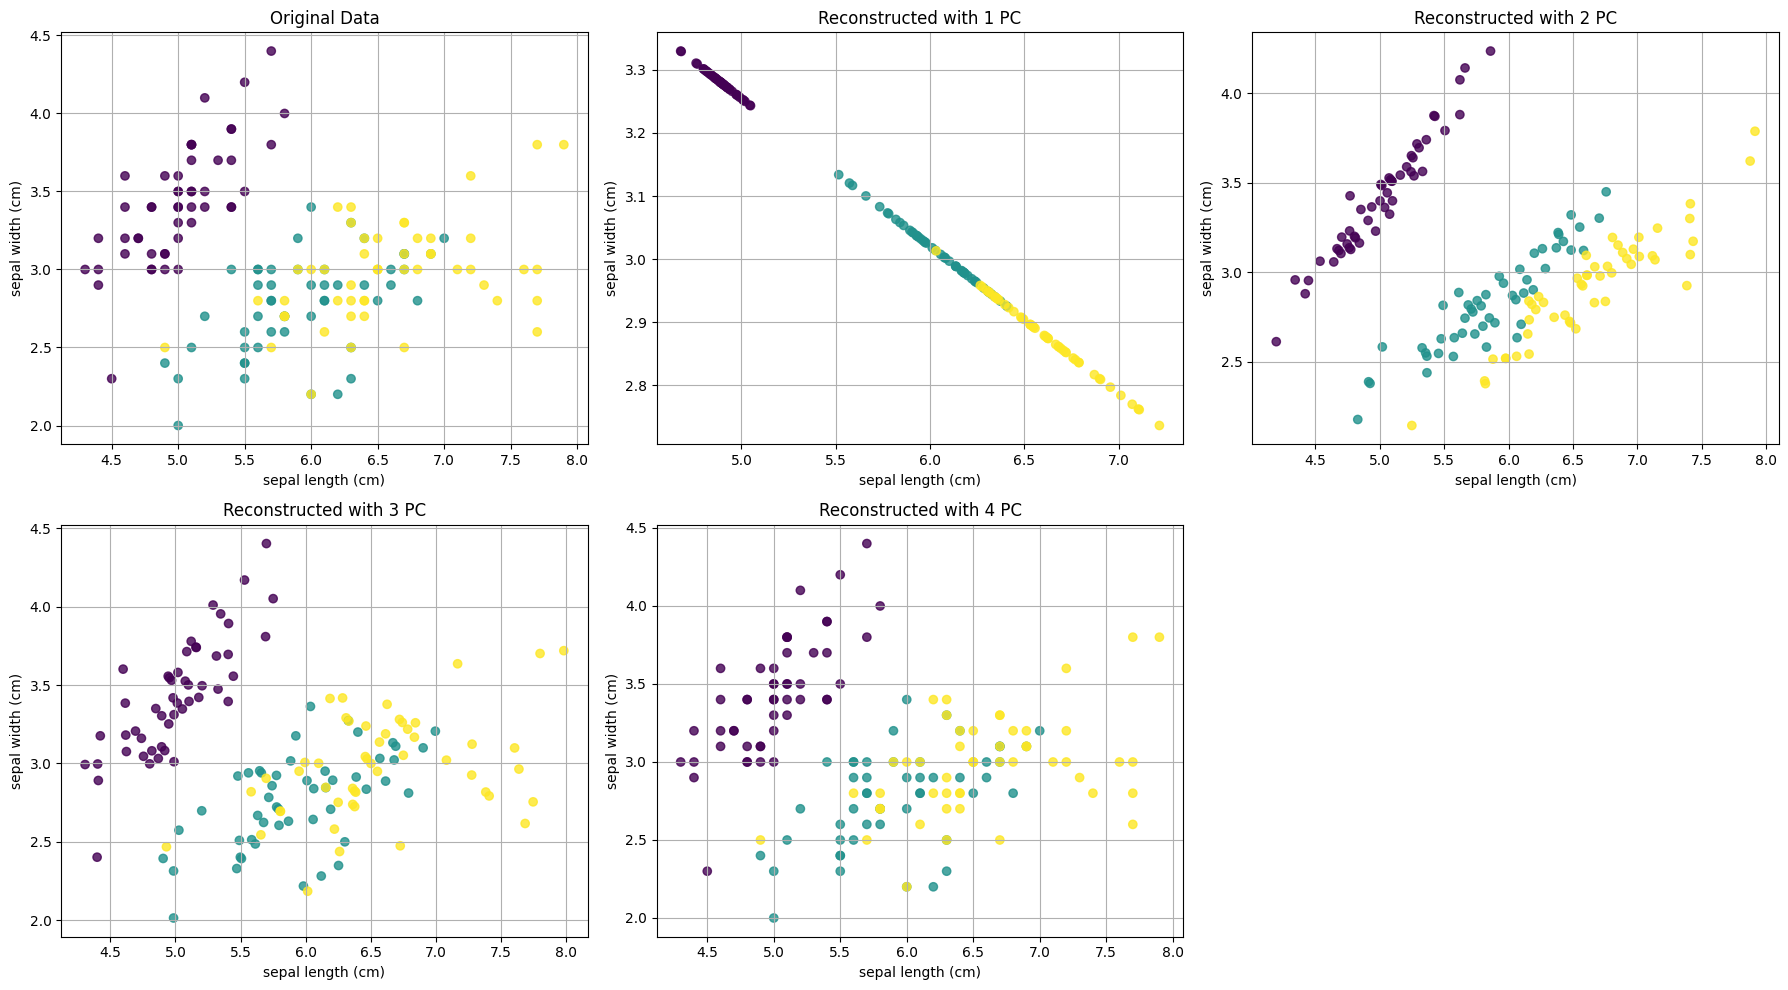

In [68]:
# Plot original vs reconstructed data for one feature pair
feature_idx = (0, 1)  # sepal length vs sepal width
plt.figure(figsize=(18, 10))

# Original data
plt.subplot(2, 3, 1)
plt.scatter(X[:, feature_idx[0]], X[:, feature_idx[1]], c=y, alpha=0.8)
plt.title('Original Data')
plt.xlabel(feature_names[feature_idx[0]])
plt.ylabel(feature_names[feature_idx[1]])
plt.grid(True)

# Reconstructed data with increasing components
for i in range(n_features):
    plt.subplot(2, 3, i + 2)
    plt.scatter(reconstructions[i][:, feature_idx[0]], 
                reconstructions[i][:, feature_idx[1]], 
                c=y, alpha=0.8)
    plt.title(f'Reconstructed with {i+1} PC')
    plt.xlabel(feature_names[feature_idx[0]])
    plt.ylabel(feature_names[feature_idx[1]])
    plt.grid(True)

plt.tight_layout()
plt.show()

### 8. PCA for Visualization
One of the most common uses of PCA is for visualizing high-dimensional data.


In [69]:
# Load a higher-dimensional dataset
from sklearn.datasets import fetch_openml

# Load the MNIST digits dataset (or a subset)
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X_mnist = mnist.data.values[:2000]  # Use 2000 samples for faster computation
y_mnist = mnist.target.astype(int).values[:2000]

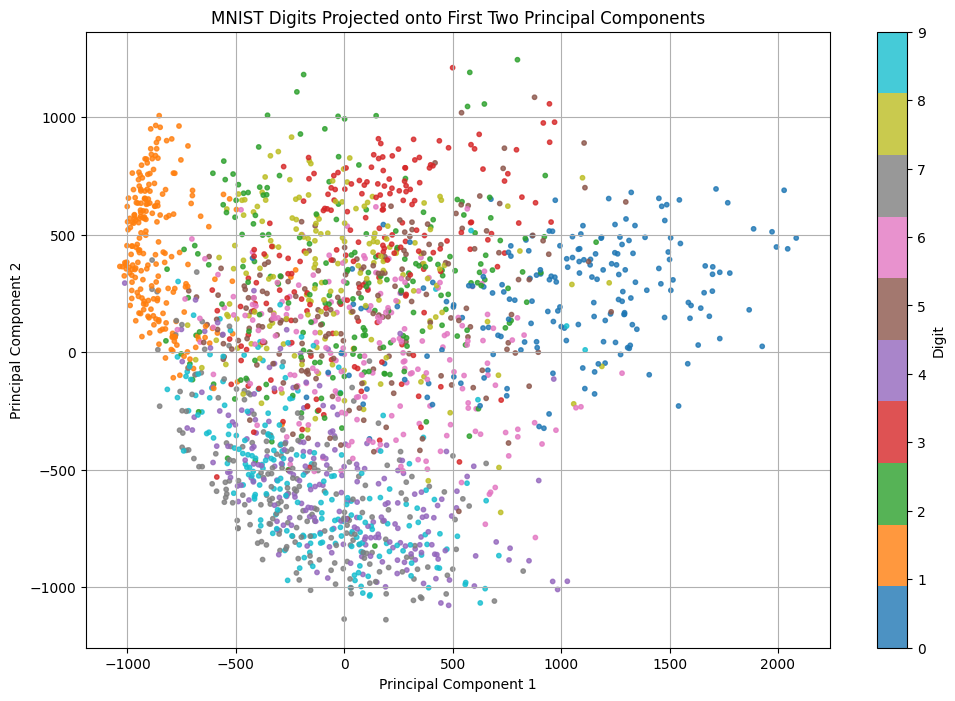

Explained variance ratio: [0.10009538 0.07460617]
Total explained variance: 0.1747


In [70]:
# Apply PCA
pca_mnist = PCA(n_components=2)
X_mnist_pca = pca_mnist.fit_transform(X_mnist)

# Plot the results
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_mnist_pca[:, 0], X_mnist_pca[:, 1], c=y_mnist, 
                      cmap='tab10', alpha=0.8, s=10)
plt.colorbar(scatter, label='Digit')
plt.title('MNIST Digits Projected onto First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

print(f"Explained variance ratio: {pca_mnist.explained_variance_ratio_}")
print(f"Total explained variance: {sum(pca_mnist.explained_variance_ratio_):.4f}")

### 9. PCA for Noise Reduction

PCA can be used to reduce noise in data by removing components with low variance.

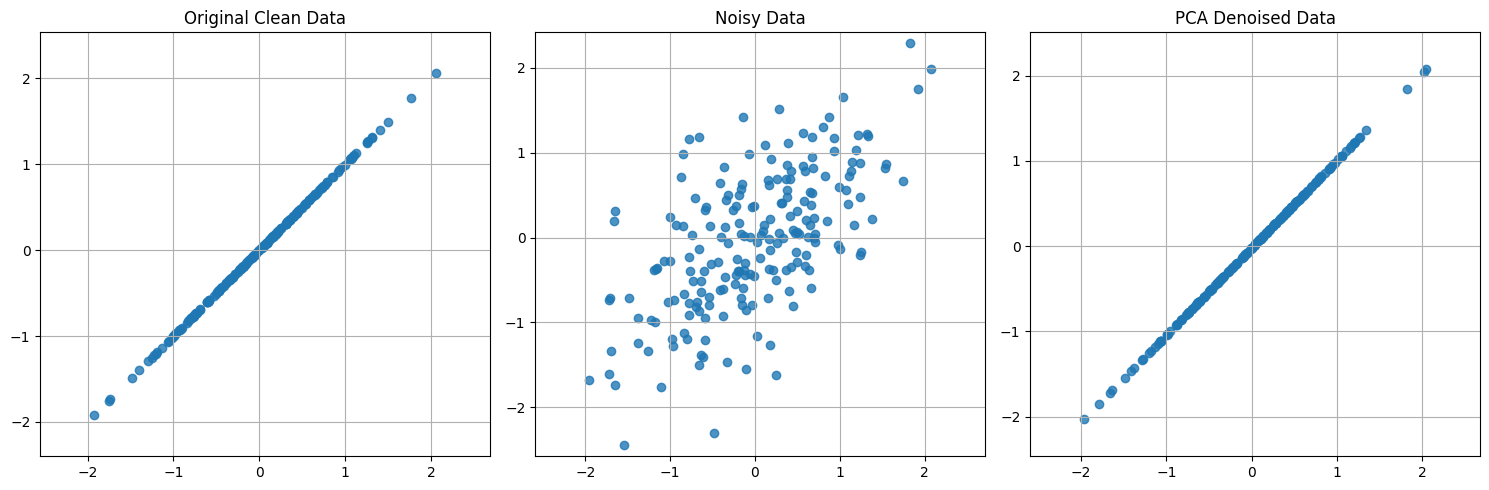

In [71]:
# Create a noisy version of a simple dataset
# First, let's create a clean 2D dataset
n_samples = 200
angle = np.pi / 4  # 45 degrees
X_clean = np.dot(np.random.randn(n_samples, 1), np.array([[np.cos(angle), np.sin(angle)]]))

# Add noise
noise_level = 0.5
X_noisy = X_clean + noise_level * np.random.randn(n_samples, 2)

# Apply PCA
pca_denoising = PCA(n_components=1)
X_denoised_pca = pca_denoising.fit_transform(X_noisy)
X_denoised = pca_denoising.inverse_transform(X_denoised_pca)

# Plot original, noisy, and denoised data
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_clean[:, 0], X_clean[:, 1], alpha=0.8)
plt.title('Original Clean Data')
plt.grid(True)
plt.axis('equal')

plt.subplot(1, 3, 2)
plt.scatter(X_noisy[:, 0], X_noisy[:, 1], alpha=0.8)
plt.title('Noisy Data')
plt.grid(True)
plt.axis('equal')

plt.subplot(1, 3, 3)
plt.scatter(X_denoised[:, 0], X_denoised[:, 1], alpha=0.8)
plt.title('PCA Denoised Data')
plt.grid(True)
plt.axis('equal')

plt.tight_layout()
plt.show()

### 10. Limitations and Considerations

While PCA is powerful, it has some limitations:

1. **Linear assumptions**: PCA assumes linear relationships between variables
2. **Sensitivity to scaling**: Results depend on how the data is scaled
3. **Interpretability**: Principal components can be difficult to interpret
4. **Outliers**: PCA is sensitive to outliers

For non-linear dimensionality reduction, consider:
- Kernel PCA
- t-SNE (t-Distributed Stochastic Neighbor Embedding)
- UMAP (Uniform Manifold Approximation and Projection)

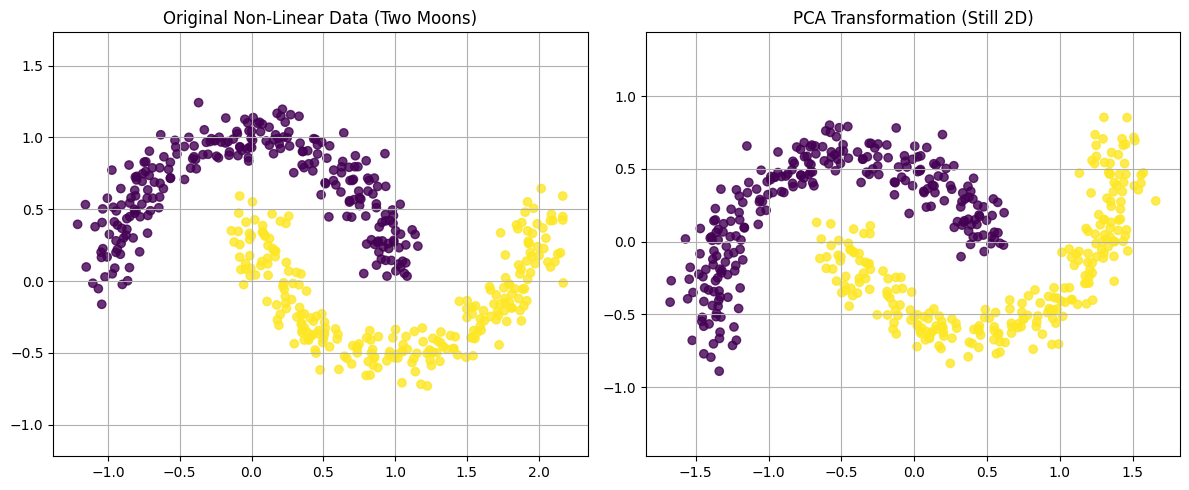

In [73]:
# Example of how PCA can fail with non-linear data structures
from sklearn.datasets import make_moons

# Create a non-linear dataset (two half-moons)
X_moons, y_moons = make_moons(n_samples=500, noise=0.1, random_state=42)

# Apply PCA
pca_moons = PCA(n_components=2)
X_moons_pca = pca_moons.fit_transform(X_moons)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, alpha=0.8)
plt.title('Original Non-Linear Data (Two Moons)')
plt.grid(True)
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.scatter(X_moons_pca[:, 0], X_moons_pca[:, 1], c=y_moons, alpha=0.8)
plt.title('PCA Transformation (Still 2D)')
plt.grid(True)
plt.axis('equal')

plt.tight_layout()
plt.show()

### Conclusion

Principal Component Analysis is a fundamental technique in the data science toolkit. In this notebook, we've explored:

1. The mathematical foundations of PCA
2. How to implement PCA from scratch and with scikit-learn
3. Visualizing the results of PCA
4. Selecting the optimal number of components
5. Applications such as dimensionality reduction, visualization, and noise reduction
6. Limitations of PCA and alternative approaches

PCA is particularly valuable as a preprocessing step for machine learning algorithms, as it can significantly reduce computation time while preserving most of the information in the data.